In [1]:
import subprocess
import os
import re
from datetime import datetime
from pathlib import Path
import json
from itertools import islice 
import pandas as pd
import networkx as nx
import random
from src.vanilla_qaoa_result import run_vanilla_qaoa


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)


In [2]:
from src.adapt_utils import (
    run_adapt_jl_parallel,
    show_adapt_logs,
    get_combined_res_df
)

# Config

In [ ]:
adapt_gpt_dir = Path(
    "/home/mrzaizai2k/code_bao/ADAPT_GPT"
)
adapt_output_dir = "./ADAPT.jl_results/test/time"
n_graphs = 5
n_runs = 1
input_graph_filename = "ADAPT.jl_results/graphs.json"


In [4]:
def add_weights_to_nx_graph(G, weighted=True, use_negative=False):
    elist = []
    for u, v in G.edges():
        if weighted:
            w = random.uniform(0.1, 1.0)
            if use_negative and random.random() < 0.5:
                w *= -1
        else:
            w = -1 if (use_negative and random.random() < 0.5) else 1

        elist.append([int(u)+1, int(v)+1, float(round(w, 2))])  
        # +1 to match Julia 1-indexing
    return elist

def generate_graphs(
    n_graphs=10,
    n_nodes=10,
    density=None,          # if None → random
    weighted=True,
    use_negative=False
):
    graphs_dict = {}

    for i in range(n_graphs):
        if density is None:
            p = random.uniform(0.6, 0.9)   # random density
        else:
            p = density

        G = nx.erdos_renyi_graph(n=n_nodes, p=p)

        # avoid empty graph
        while G.number_of_edges() == 0:
            G = nx.erdos_renyi_graph(n=n_nodes, p=p)

        elist = add_weights_to_nx_graph(G, weighted, use_negative)

        graph_name = f"Graph_{i}_n{n_nodes}"

        graphs_dict[graph_name] = {
            "elist": elist,
            "n_nodes": n_nodes
        }

    return graphs_dict

def load_graphs(filename):
    with open(filename, "r") as f:
        return json.load(f)
    

def save_graphs_to_json(graphs_dict, filename):
    with open(filename, "w") as f:
        json.dump(graphs_dict, f, indent=2)

# Generate graphs

In [7]:
path_list=[]
for i in [4, 6, 8, 10, 11]:
    graphs = generate_graphs(
        n_graphs=n_graphs,
        n_nodes=i,
        density=None,          # or e.g. 0.7
        weighted=True,
        use_negative=False
    )
    path = f"{adapt_output_dir}/graphs_n{i}.json"

    save_graphs_to_json(graphs, path)
    path_list.append(path)

# Load back
cur_input_graphs_dict = load_graphs(path)


# ADAPT QAOA result

In [8]:

adapt_folder_list =[]
for path in path_list:
    filename = os.path.basename(path)
    match = re.search(r"graphs_n(\d+)", filename)
    
    if not match:
        raise ValueError(f"Cannot extract node number from {filename}")
    
    i = int(match.group(1))  # convert to int

    new_name = f"{adapt_output_dir}/graphs_n{i}/"
    adapt_folder_list.append(new_name)

    logs_list, cur_proc = run_adapt_jl_parallel(
        script_dir=adapt_gpt_dir,
        output_dir=new_name,
        input_graphs=path,
        n_workers=1,
        graphs_number=n_graphs,
        n_nodes=i,  
        trials_per_graph=n_runs,
        max_params=50,
        gamma_0="gamma0_grid.json",
        pool_name="qaoa_double_pool",
        use_floor_stopper=True,
        temp_folder=f"{adapt_output_dir}/temp_data_n{i}",
    )

Splitting input graphs into 1 parts
Starting worker 0 on node: DESKTOP-H2CRQMR
Splitting input graphs into 1 parts
Starting worker 0 on node: DESKTOP-H2CRQMR
Splitting input graphs into 1 parts
Starting worker 0 on node: DESKTOP-H2CRQMR
Splitting input graphs into 1 parts
Starting worker 0 on node: DESKTOP-H2CRQMR
Splitting input graphs into 1 parts
Starting worker 0 on node: DESKTOP-H2CRQMR


In [18]:
show_adapt_logs(logs_list, n_lines=20)

Log: worker_DESKTOP-H2CRQMR_0

Number of callbacks: 6
Exact energy (MQLib): -16.32
Running with optimizer: BFGS
For QAOA reading gamma_0 values from: gamma0_grid.json
For QAOA using gamma_0 = 0.01, trial: 1/1, graph N: 2/2
Success!
final energy:	-15.986691275440599 (through trace)
Took time: 8.44 sec.;
N layers: 11;
g0 = 0.01;
ar = 0.9795766712892524
Good approx ratio achieved with g0 = 0.01, skipping other g0s

Graphs on: unknown; pid: 32717: 100.0%┣█████████████┫ 2/2 [01:55<00:00, 115s/it]

Graphs on: unknown; pid: 32717: 100.0%┣█████████████┫ 2/2 [01:55<00:00, 115s/it]

hostname: unknown; pid: 32717; The script took: 115.42455005645752 seconds.


--------------------------------------------------


# QAOA result

In [19]:
adapt_folder_list

['./ADAPT.jl_results/test/time/graphs_n4/',
 './ADAPT.jl_results/test/time/graphs_n6/',
 './ADAPT.jl_results/test/time/graphs_n8/',
 './ADAPT.jl_results/test/time/graphs_n10/',
 './ADAPT.jl_results/test/time/graphs_n11/']

In [20]:
for path in adapt_folder_list:
    qaoa_df = run_vanilla_qaoa(
        data_path=path,
        depth=None,
        n_samples=None,
        n_runs=1
    )


=== RUN 1/1 ===
Running graph_1...
2026-05-04 21:15:13 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape


2026-05-04 21:15:13 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-05-04 21:15:13 [info     ] circuits: 400                  file=qaoa.qaoa func=sample_cost_landscape
2026-05-04 21:15:13 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-05-04 21:15:14 [info     ] Done measurement               file=qaoa.qaoa func=sample_cost_landscape
2026-05-04 21:15:14 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape
2026-05-04 21:15:14 [info     ] cost(depth 1 = -2.55869140625  file=qaoa.qaoa func=optimize
2026-05-04 21:15:15 [info     ] cost(depth 2 = -2.2926367187499994 file=qaoa.qaoa func=optimize
2026-05-04 21:15:16 [info     ] cost(depth 3 = -2.3222070312499996 file=qaoa.qaoa func=optimize
2026-05-04 21:15:17 [info     ] cost(depth 4 = -1.48853515625  file=qaoa.qaoa func=optimize
Saved result for graph_1
Running graph_2...
2026-05-04 21:15:17 [info     ] Calculating energy 

In [21]:
qaoa_df.head()

,graph_name,n_nodes,edgelist_list_len,n_layers,expected_energy,variance,γ_coeff,β_coeff,approx_ratio,energy_mqlib,edgelist_list,took_time,method,optimizer,run_id
0,graph_1,11,43,11,-13.564902,1.484707,"[0.544756256919212, 0.5770013652666147, 0.5934693446693753, 0.58386404234527, 0.5881778374106522, 0.6158405611702618, 0.645000836922426, 0.6487558023564473, 0.6239216432970862, 0.5674234196798994, 0.37614626444264015]","[3.6225694183566235, 3.481965232518991, 3.3816251273424034, 3.3480955854031373, 3.348857349458385, 3.3415847195222215, 3.310287277552526, 3.2654266658241515, 3.2336899264737933, 3.2340697400193807, 3.2490265002273233]",0.943317,-14.38,"[[1, 2, 0.17], [1, 4, 0.41], [1, 5, 0.53], [1, 6, 0.13], [1, 7, 0.4], [1, 8, 0.32], [2, 4, 0.94], [2, 5, 0.34], [2, 6, 0.62], [2, 7, 0.12], [2, 8, 0.79], [2, 9, 0.41], [2, 10, 0.51], [2, 11, 0.53], [4, 3, 0.27], [4, 5, 0.99], [4, 6, 0.22], [4, 10, 0.11], [4, 11, 0.18], [3, 5, 0.42], [3, 7, 0.15], [3, 8, 0.63], [3, 9, 0.27], [3, 11, 0.56], [5, 6, 0.23], [5, 7, 0.43], [5, 8, 0.85], [5, 9, 0.54], [5, 10, 0.48], [5, 11, 0.27], [6, 7, 0.74], [6, 9, 0.97], [6, 10, 0.72], [6, 11, 0.31], [7, 8, 0.3], [7, 9, 0.63], [7, 10, 0.38], [7, 11, 0.96], [8, 9, 0.74], [8, 10, 0.17], [9, 10, 0.7], [9, 11, 0.82], [10, 11, 0.3]]",145.287,vanilla_qaoa,BFGS,0
1,graph_2,11,41,11,-14.993643,2.385006,"[0.4496018023989165, 0.46942689897499246, 0.4892745715876292, 0.5090994397596558, 0.5289371893750321, 0.5487466626098497, 0.5685555984442611, 0.5884069783837786, 0.6082268689399991, 0.628011348638176, 0.6478510661049033]","[1.9164009462569491, 1.9059203959673245, 1.8954612015320826, 1.884985027085511, 1.8745327166446204, 1.8640072459174677, 1.8535350107541924, 1.8430576977558664, 1.8326110969199476, 1.8221426779385934, 1.811707077139377]",0.918728,-16.32,"[[1, 3, 0.27], [1, 4, 0.44], [1, 6, 0.19], [1, 7, 0.62], [1, 8, 0.64], [1, 9, 0.44], [1, 10, 0.64], [3, 2, 0.58], [3, 5, 0.41], [3, 6, 0.86], [3, 8, 0.59], [3, 9, 0.19], [3, 10, 0.27], [3, 11, 0.9], [2, 4, 0.78], [2, 5, 0.44], [2, 6, 0.35], [2, 7, 0.98], [2, 8, 0.29], [2, 9, 0.5], [2, 10, 0.87], [2, 11, 0.44], [4, 6, 0.53], [4, 8, 0.67], [5, 6, 0.76], [5, 7, 0.87], [5, 8, 0.86], [5, 10, 0.75], [6, 7, 0.32], [6, 8, 0.29], [6, 9, 0.93], [6, 10, 0.51], [6, 11, 0.68], [7, 8, 0.77], [7, 9, 0.33], [7, 10, 0.9], [8, 9, 0.61], [8, 10, 0.91], [8, 11, 0.32], [9, 10, 0.13], [9, 11, 0.49]]",161.045,vanilla_qaoa,BFGS,0


# LLMs

In [53]:
# ------------------------
# IMPORTS
# ------------------------
import time
import numpy as np
import torch
import glob
# from src.adapt_utils import compute_metrics_per_graph
from src.model_interface import QAOA_GPT
from src.utils import (
    # attach_resolved_names,
    load_and_aggregate_adapt,
    # build_results_df,
    # build_final_df,
    # build_summary_df,
)

pd.set_option("display.max_columns", None)

In [60]:

# ── Config ──────────────────────────────────────────────────
BASE_DIR        = "ADAPT.jl_results/test/time"
MODEL_CKPT      = "nanoGPT/out-11_nodes_feather/gpt_ckpt_3000_feather_ar_0_96249__er_0_0.pt"
DATA_DIR        = "nanoGPT/data/11_nodes_feather"
MAX_TOKENS      = 200
LLM_TEMPERATURE = 0.1
LLM_TOP_K       = 200
# ───────────────────────

In [61]:


def get_graph_folders(base_dir: str) -> list[str]:
    """Return all graphs_nXX sub-folders (directories only), sorted by node count."""
    pattern = os.path.join(base_dir, "graphs_n*")
    folders = sorted([
        p for p in glob.glob(pattern)
        if os.path.isdir(p)  # skip files like graphs_n10.json
    ])
    return folders

def qaoa_time_mean(folder: str) -> tuple[float, int]:
    """
    Find the single qaoa_*.csv inside <folder>/qaoa_result/,
    compute per-graph mean time across run_ids, then grand-mean.
    """
    qaoa_dir = os.path.join(folder, "qaoa_result")
    matches = glob.glob(os.path.join(qaoa_dir, "qaoa_*.csv"))

    if not matches:
        raise FileNotFoundError(f"No qaoa_*.csv found in {qaoa_dir}")

    csv_path = matches[0]  # only one file expected
    print(f"        Reading: {csv_path}")
    df = pd.read_csv(csv_path)

    n_runs = df["run_id"].nunique()

    # mean took_time per graph across run_ids, then grand mean
    per_graph = df.groupby("graph_name")["took_time"].mean()
    grand_mean = per_graph.mean()

    return grand_mean, n_runs


def adapt_time_mean(folder: str) -> tuple[float, int]:
    """
    Use load_and_aggregate_adapt to get adapt_agg, then return
    the mean of adapt_time_mean across all graphs in that folder.

    Returns
    -------
    mean_time_per_run : float
    n_runs            : int
    """
    _, adapt_agg, _, _ = load_and_aggregate_adapt(folder)

    # adapt_time_mean column = mean wall-clock seconds per run for each graph
    mean_time = adapt_agg["adapt_time_mean"].mean()
    n_runs = int(adapt_agg["adapt_n_runs"].mode()[0])  # most common run count

    return mean_time, n_runs


In [62]:

def llm_time_mean(
    folder: str,
    graphs_unique,
    n_runs: int,
    n_nodes: int,
) -> float:
    """
    Run QAOA_GPT.generate_circ_from_nx on *graphs_unique* and measure
    wall-clock time.  The model's `took_time` column is the total seconds
    for *n_runs* samples, so we divide by n_runs to get per-run time.

    Returns
    -------
    mean_time_per_run : float
    """
    model = QAOA_GPT(model_ckpt=MODEL_CKPT, data_dir=DATA_DIR)
    model.n_nodes = n_nodes

    t0 = time.perf_counter()
    df_model = model.generate_circ_from_nx(
        graphs_unique,
        num_samples=n_runs,
        max_new_tokens=MAX_TOKENS,
        temperature=LLM_TEMPERATURE,
        top_k=LLM_TOP_K,
    )
    total_wall = time.perf_counter() - t0

    # `took_time` in df_model is total seconds for all n_runs on that graph
    if "took_time" in df_model.columns:
        # per-graph, per-run mean from the model's own timer
        per_run = df_model["took_time"].sum() / (len(df_model) * n_runs)
    else:
        # fallback: use wall-clock divided by (n_graphs * n_runs)
        per_run = total_wall / (len(graphs_unique) * n_runs)

    return per_run


In [63]:

def build_timing_summary() -> pd.DataFrame:
    folders = get_graph_folders(BASE_DIR)
    if not folders:
        raise FileNotFoundError(f"No graphs_nXX folders found under {BASE_DIR}")

    records = []

    for folder in folders:
        # Infer n_nodes from folder name  (e.g. graphs_n10 → 10)
        folder_name = os.path.basename(folder)                   # graphs_n10
        n_nodes = int(folder_name.replace("graphs_n", ""))

        print(f"\n{'='*55}")
        print(f"Processing {folder_name}  (n_nodes={n_nodes})")
        print(f"{'='*55}")

        # ── 1. QAOA timing ──────────────────────────────────
        print("  [1/3] Reading QAOA times …")
        try:
            qaoa_mean, n_runs_qaoa = qaoa_time_mean(folder)
            print(f"        QAOA mean time/run = {qaoa_mean:.4f}s  (n_runs={n_runs_qaoa})")
        except FileNotFoundError:
            print("        qaoa_result not found – skipping QAOA.")
            qaoa_mean, n_runs_qaoa = np.nan, np.nan

        # ── 2. ADAPT timing ─────────────────────────────────
        print("  [2/3] Loading ADAPT aggregation …")
        try:
            adapt_mean, n_runs_adapt = adapt_time_mean(folder)
            print(f"        ADAPT mean time/run = {adapt_mean:.4f}s  (n_runs={n_runs_adapt})")
        except Exception as e:
            print(f"        ADAPT load failed: {e}")
            adapt_mean, n_runs_adapt = np.nan, np.nan

        # n_runs to use for LLM (prefer ADAPT's count, fallback QAOA's)
        n_runs = int(n_runs_adapt if not np.isnan(n_runs_adapt) else n_runs_qaoa)

        # ── 3. LLM timing ───────────────────────────────────
        print(f"  [3/3] Running LLM inference  (n_runs={n_runs}) …")
        try:
            # We need graphs_unique from ADAPT loader
            _, _, graphs_unique, _ = load_and_aggregate_adapt(folder)
            llm_mean = llm_time_mean(folder, graphs_unique, n_runs, n_nodes)
            print(f"        LLM mean time/run  = {llm_mean:.4f}s")
        except Exception as e:
            print(f"        LLM inference failed: {e}")
            llm_mean = np.nan

        records.append({
            "folder":                folder_name,
            "n_nodes":               n_nodes,
            "n_runs":                n_runs,
            "qaoa_time_mean_s":      round(qaoa_mean,  6),
            "adapt_time_mean_s":     round(adapt_mean, 6),
            "llm_time_mean_s":       round(llm_mean,   6),
        })

    summary_df = (
        pd.DataFrame(records)
        .sort_values("n_nodes")
        .reset_index(drop=True)
    )
    return summary_df


In [64]:
summary = build_timing_summary()

print(summary.to_string(index=False))


Processing graphs_n10  (n_nodes=10)
  [1/3] Reading QAOA times …
        Reading: ADAPT.jl_results/test/time/graphs_n10/qaoa_result/qaoa_04_21_16.csv
        QAOA mean time/run = 93.3495s  (n_runs=1)
  [2/3] Loading ADAPT aggregation …
Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/time/graphs_n10


Opening ADAPT results (graphs_n10): 100%|██████████| 1/1 [00:00<00:00, 340.70it/s]


df_list len: 1


Opening graphs (graphs_n10): 100%|██████████| 1/1 [00:00<00:00, 492.75it/s]


df_list len: 1
Graphs count:
g_method
input_file    2
Name: count, dtype: int64
Aggregating results...
Total ADAPT rows      : 3
Unique graphs         : 1
Runs per graph (mean) : 3.00

Aggregated ADAPT shape : (1, 9)
Graphs fed to model    : 1
        ADAPT mean time/run = 5.9913s  (n_runs=3)
  [3/3] Running LLM inference  (n_runs=3) …
Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/time/graphs_n10


...

df_list len: 1
Graphs count:
g_method
input_file    2
Name: count, dtype: int64
Aggregating results...
Total ADAPT rows      : 3
Unique graphs         : 1
Runs per graph (mean) : 3.00

Aggregated ADAPT shape : (1, 9)
Graphs fed to model    : 1

Model type: gpt
Pool type: qaoa_double_pool
Embedding method: feather
Number of nodes: 11
Initiating nanoGPT model with padding support
number of parameters: 11.71M


Preparing graphs...: 100%|██████████| 1/1 [00:00<00:00, 378.34it/s]


Performing feather embedding


100%|██████████| 1/1 [00:00<00:00, 491.14it/s]
Inference. Current batch: n_edges: 17, n_graphs: 1: 100%|██████████| 1/1 [00:00<00:00,  1.49it/s]

        LLM mean time/run  = 0.2296s
    folder  n_nodes  n_runs  qaoa_time_mean_s  adapt_time_mean_s  llm_time_mean_s
 graphs_n4        4       2            3.7900           2.008360         0.348956
 graphs_n6        6       3            9.9570           1.436141         0.207607
 graphs_n8        8       3           28.7020           2.057660         0.229589
graphs_n10       10       3           93.3495           5.991292         0.237610
graphs_n11       11       3          153.1660          30.434287         0.234390


In [66]:
summary.head()

,folder,n_nodes,n_runs,qaoa_time_mean_s,adapt_time_mean_s,llm_time_mean_s
0,graphs_n4,4,2,3.7900,2.008360,0.348956
1,graphs_n6,6,3,9.9570,1.436141,0.207607
2,graphs_n8,8,3,28.7020,2.057660,0.229589
3,graphs_n10,10,3,93.3495,5.991292,0.237610
4,graphs_n11,11,3,153.1660,30.434287,0.234390


In [67]:
summary.to_csv(f"ADAPT.jl_results/test/time/summary.csv", index=False)

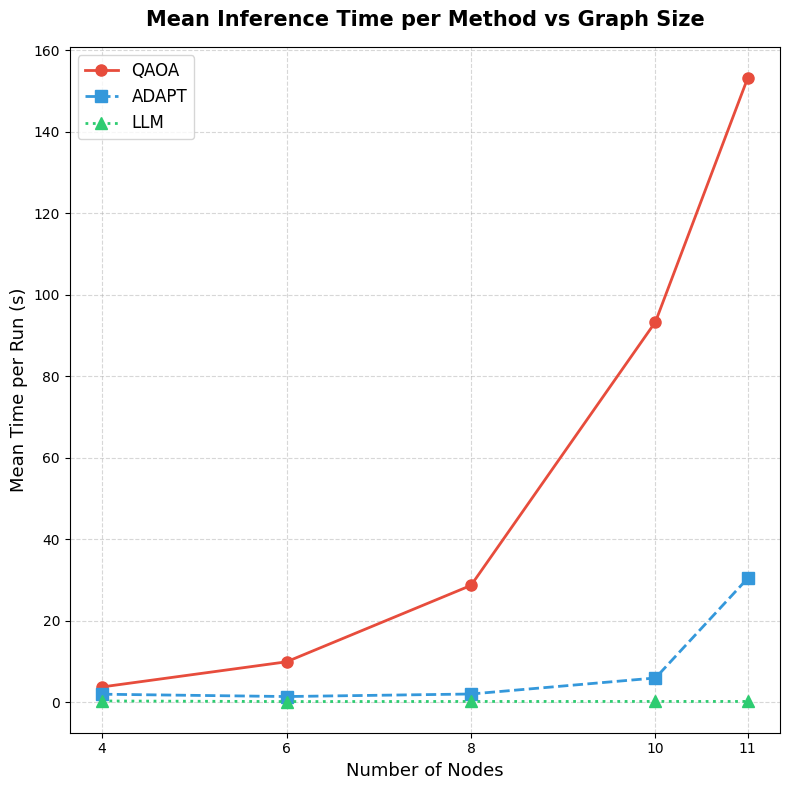

In [71]:
import matplotlib.pyplot as plt

def plot_timing_comparison(summary_df: pd.DataFrame, save_path: str = None, log_scale = False):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    methods = {
        "QAOA":  ("qaoa_time_mean_s",  "o-",  "#E74C3C"),
        "ADAPT": ("adapt_time_mean_s", "s--", "#3498DB"),
        "LLM":   ("llm_time_mean_s",   "^:",  "#2ECC71"),
    }
    
    for label, (col, style, color) in methods.items():
        ax.plot(
            summary_df["n_nodes"],
            summary_df[col],
            style,
            color=color,
            linewidth=2,
            markersize=8,
            label=label,
        )
    
    ax.set_title("Mean Inference Time per Method vs Graph Size", fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel("Number of Nodes", fontsize=13)
    ax.set_ylabel("Mean Time per Run (s)", fontsize=13)
    ax.set_xticks(summary_df["n_nodes"])
    ax.legend(fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.5)
    if log_scale:
        ax.set_yscale("log")
        ax.set_ylabel("Mean Time per Run (s) — log scale", fontsize=13)
    else:
        ax.set_ylabel("Mean Time per Run (s)", fontsize=13)

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved → {save_path}")
    
    plt.show()



plot_timing_comparison(summary)